<a href="https://colab.research.google.com/github/NinaNikolova/data_mining_project/blob/main/python_games17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Обучение на ансамбъл модел за анализ на ревюта за видео игри симулиращ невронни мрежи


In [3]:
from google.colab import drive
drive.mount('/content/drive')
from google.colab import files
uploaded = files.upload()

Mounted at /content/drive


Saving video_game_reviews.csv to video_game_reviews.csv


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR, LinearSVR, OneClassSVM
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

from sklearn.svm import LinearSVC,  LinearSVR, SVC
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import joblib
import warnings
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import VotingClassifier, StackingClassifier
warnings.filterwarnings('ignore')

 Зареждане на CSV файла
 Loading CSV file

In [4]:
df = pd.read_csv('/content/video_game_reviews.csv')
df.head()

,Game Title,User Rating,Age Group Targeted,Price,Platform,Requires Special Device,Developer,Publisher,Release Year,Genre,Multiplayer,Game Length (Hours),Graphics Quality,Soundtrack Quality,Story Quality,User Review Text,Game Mode,Min Number of Players
0,Grand Theft Auto V,36.4,All Ages,41.41,PC,No,Game Freak,Innersloth,2015,Adventure,No,55.3,Medium,Average,Poor,"Solid game, but too many bugs.",Offline,1
1,The Sims 4,38.3,Adults,57.56,PC,No,Nintendo,Electronic Arts,2015,Shooter,Yes,34.6,Low,Poor,Poor,"Solid game, but too many bugs.",Offline,3
2,Minecraft,26.8,Teens,44.93,PC,Yes,Bungie,Capcom,2012,Adventure,Yes,13.9,Low,Good,Average,"Great game, but the graphics could be better.",Offline,5
3,Bioshock Infinite,38.4,All Ages,48.29,Mobile,Yes,Game Freak,Nintendo,2015,Sports,No,41.9,Medium,Good,Excellent,"Solid game, but the graphics could be better.",Online,4
4,Half-Life: Alyx,30.1,Adults,55.49,PlayStation,Yes,Game Freak,Epic Games,2022,RPG,Yes,13.2,High,Poor,Good,"Great game, but too many bugs.",Offline,1


Stochastic Gradient Descent-метод за обучение на линейни модели (като SVM или логистична регресия), който работи добре при големи количества данни. loss='hinge' задава hinge функция за загуба, която се използва в линейните Support Vector Machines (SVM).

Тази функция наказва грешните предсказания, като се стреми границата на разделяне между класовете да е максимално широка.

In [41]:
# Обработка на данните и създаване на категории
# Data processing and category creation
def process_data(df):
    """
    Обработва данните и създава категории за класификация
    Processes data and creates categories for classification
    """
    print("🔄 Обработка на данните... / Processing data...")

    # Изчисляване на средния рейтинг
    # Calculate mean rating
    mean_rating = df['User Rating'].mean()
    print(f"Среден рейтинг: {mean_rating:.2f}")

    # Създаване на категории „low" и „high"
    # Create "low" and "high" categories
    df['rating_category'] = df['User Rating'].apply(lambda x: 'low' if x <= mean_rating else 'high')

    print(f"Разпределение на категориите:")
    print(df['rating_category'].value_counts())

    # TF-IDF векторизация на текста
    # TF-IDF vectorization of text
    print(" TF-IDF векторизация... / TF-IDF vectorization...")
    vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
    X = vectorizer.fit_transform(df['User Review Text'])
    y = df['User Rating']

    print(f"Характеристики: {X.shape}")
    print(f"Целева променлива: {len(y)} образци")

    return X, y, vectorizer, df

In [42]:
sgd = SGDClassifier(loss='hinge',  random_state=42, max_iter=1000)
sgd

SGDClassifier(random_state=42)

Създаваме 20 SGD класификатора с различни параметри - създаване на ансамбъл от модели, което може да подобри стабилността и точността чрез комбиниране на техните прогнози

In [25]:
units  = [(f"sgd_{i}", SGDClassifier(loss='hinge')) for i in range(20)]

voting = *слой*
VotingClassifier комбинира предсказанията на множество класификатори (в случая 20 SGDClassifier модела) чрез гласуване.
По подразбиране VotingClassifier използва hard voting, което означава, че всеки модел дава предсказание за класа (напр. „положителен“ или „отрицателен“), а крайният резултат е класът с най-много гласове.
Това е форма на ансамблово обучение, което намалява риска от прекомерно напасване (overfitting) и подобрява обобщаващата способност на модела.

In [27]:
layer = VotingClassifier(units)
layer

VotingClassifier(estimators=[('sgd_0', SGDClassifier()),
                             ('sgd_1', SGDClassifier()),
                             ('sgd_2', SGDClassifier()),
                             ('sgd_3', SGDClassifier()),
                             ('sgd_4', SGDClassifier()),
                             ('sgd_5', SGDClassifier()),
                             ('sgd_6', SGDClassifier()),
                             ('sgd_7', SGDClassifier()),
                             ('sgd_8', SGDClassifier()),
                             ('sgd_9', SGDClassifier()),
                             ('sgd_10', SGDClassifier()),
                             ('sgd_11', SGDClassifier()),
                             ('sgd_12', SGDClassifier()),
                             ('sgd_13', SGDClassifier()),
                             ('sgd_14', SGDClassifier()),
                             ('sgd_15', SGDClassifier()),
                             ('sgd_16', SGDClassifier()),
                             ('sgd_17', SGDClassifier()),
                             ('sgd_18', SGDClassifier()),
                             ('sgd_19', SGDClassifier())])

Тук се създават 5 VotingClassifier модела, всеки от които комбинира 20 SGDClassifier-а.
Това добавя още един слой на ансамблово обучение. Всеки VotingClassifier ще обединява предсказанията на своите 20 SGDClassifier-а, но различните VotingClassifier-и могат да имат различни резултати, ако данните или параметрите се променят (например, чрез различно разделяне на данните или различен random state).

In [28]:
nn = [(f"voting_{i}", VotingClassifier(units)) for i in range(5)]
nn

[('voting_0',
  VotingClassifier(estimators=[('sgd_0', SGDClassifier()),
                               ('sgd_1', SGDClassifier()),
                               ('sgd_2', SGDClassifier()),
                               ('sgd_3', SGDClassifier()),
                               ('sgd_4', SGDClassifier()),
                               ('sgd_5', SGDClassifier()),
                               ('sgd_6', SGDClassifier()),
                               ('sgd_7', SGDClassifier()),
                               ('sgd_8', SGDClassifier()),
                               ('sgd_9', SGDClassifier()),
                               ('sgd_10', SGDClassifier()),
                               ('sgd_11', SGDClassifier()),
                               ('sgd_12', SGDClassifier()),
                               ('sgd_13', SGDClassifier()),
                               ('sgd_14', SGDClassifier()),
                               ('sgd_15', SGDClassifier()),
                               ('sgd

StackingClassifier е метод за ансамблово обучение, който комбинира предсказанията на множество базови модели (в случая 5 VotingClassifier-а) чрез мета-класификатор.
StackingClassifier обучава мета-класификатор (по подразбиране е логистична регресия в scikit-learn), който използва предсказанията на базовите модели като входни характеристики, за да направи финално предсказание.
Това е мощна техника, защото позволява на модела да научи как да комбинира предсказанията на различните VotingClassifier-и по оптимален начин.

In [46]:
model = StackingClassifier(nn)
model

StackingClassifier(estimators=[('voting_0',
                                VotingClassifier(estimators=[('sgd_0',
                                                              SGDClassifier()),
                                                             ('sgd_1',
                                                              SGDClassifier()),
                                                             ('sgd_2',
                                                              SGDClassifier()),
                                                             ('sgd_3',
                                                              SGDClassifier()),
                                                             ('sgd_4',
                                                              SGDClassifier()),
                                                             ('sgd_5',
                                                              SGDClassifier()),
                                                             ('sgd_6',
                                                              SGDClassifier()),
                                                             ('sgd_7',
                                                              SGDClassifier()),
                                                             ('sgd_8',
                                                              SGDClassifier()),
                                                             ('sgd_9',
                                                              SGDClassifier()),
                                                             ('sgd_10',
                                                              SGDClass...
                                                             ('sgd_7',
                                                              SGDClassifier()),
                                                             ('sgd_8',
                                                              SGDClassifier()),
                                                             ('sgd_9',
                                                              SGDClassifier()),
                                                             ('sgd_10',
                                                              SGDClassifier()),
                                                             ('sgd_11',
                                                              SGDClassifier()),
                                                             ('sgd_12',
                                                              SGDClassifier()),
                                                             ('sgd_13',
                                                              SGDClassifier()),
                                                             ('sgd_14',
                                                              SGDClassifier()),
                                                             ('sgd_15',
                                                              SGDClassifier()),
                                                             ('sgd_16',
                                                              SGDClassifier()),
                                                             ('sgd_17',
                                                              SGDClassifier()),
                                                             ('sgd_18',
                                                              SGDClassifier()),
                                                             ('sgd_19',
                                                              SGDClassifier())]))])

Ако наборът съдържа текстови рецензии, трябва да ги преобразуваме в числови характеристики. Популярна техника е TF-IDF (Term Frequency-Inverse Document Frequency):

In [52]:
mean_rating = df["User Rating"].mean()
df["Rating Category"] = df["User Rating"].apply(lambda x: "low" if x < mean_rating else "high")
le = LabelEncoder()
df["Rating Encoded"] = le.fit_transform(df["Rating Category"])
X = df.drop(columns=["User Rating", "Rating Category", "Rating Encoded"])
X = X.select_dtypes(include=["number"])  # Само числови колони
y = df["Rating Encoded"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [53]:
# Обучение
# Training
model.fit(X_train, y_train)

StackingClassifier(estimators=[('voting_0',
                                VotingClassifier(estimators=[('sgd_0',
                                                              SGDClassifier()),
                                                             ('sgd_1',
                                                              SGDClassifier()),
                                                             ('sgd_2',
                                                              SGDClassifier()),
                                                             ('sgd_3',
                                                              SGDClassifier()),
                                                             ('sgd_4',
                                                              SGDClassifier()),
                                                             ('sgd_5',
                                                              SGDClassifier()),
                                                             ('sgd_6',
                                                              SGDClassifier()),
                                                             ('sgd_7',
                                                              SGDClassifier()),
                                                             ('sgd_8',
                                                              SGDClassifier()),
                                                             ('sgd_9',
                                                              SGDClassifier()),
                                                             ('sgd_10',
                                                              SGDClass...
                                                             ('sgd_7',
                                                              SGDClassifier()),
                                                             ('sgd_8',
                                                              SGDClassifier()),
                                                             ('sgd_9',
                                                              SGDClassifier()),
                                                             ('sgd_10',
                                                              SGDClassifier()),
                                                             ('sgd_11',
                                                              SGDClassifier()),
                                                             ('sgd_12',
                                                              SGDClassifier()),
                                                             ('sgd_13',
                                                              SGDClassifier()),
                                                             ('sgd_14',
                                                              SGDClassifier()),
                                                             ('sgd_15',
                                                              SGDClassifier()),
                                                             ('sgd_16',
                                                              SGDClassifier()),
                                                             ('sgd_17',
                                                              SGDClassifier()),
                                                             ('sgd_18',
                                                              SGDClassifier()),
                                                             ('sgd_19',
                                                              SGDClassifier())]))])

In [54]:
# Предсказания
y_pred = model.predict(X_test)

In [55]:
# Оценка
accuracy = accuracy_score(y_test, y_pred)
print(f"Точност / Accuracy: {accuracy:.4f}")

Точност / Accuracy: 0.9422


In [57]:
# Детайлен отчет
print("\n Детайлен отчет / Classification Report:")
print(classification_report(y_test, y_pred))


📋 Детайлен отчет / Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      4793
           1       0.96      0.92      0.94      4762

    accuracy                           0.94      9555
   macro avg       0.94      0.94      0.94      9555
weighted avg       0.94      0.94      0.94      9555



Създаване на визуализации


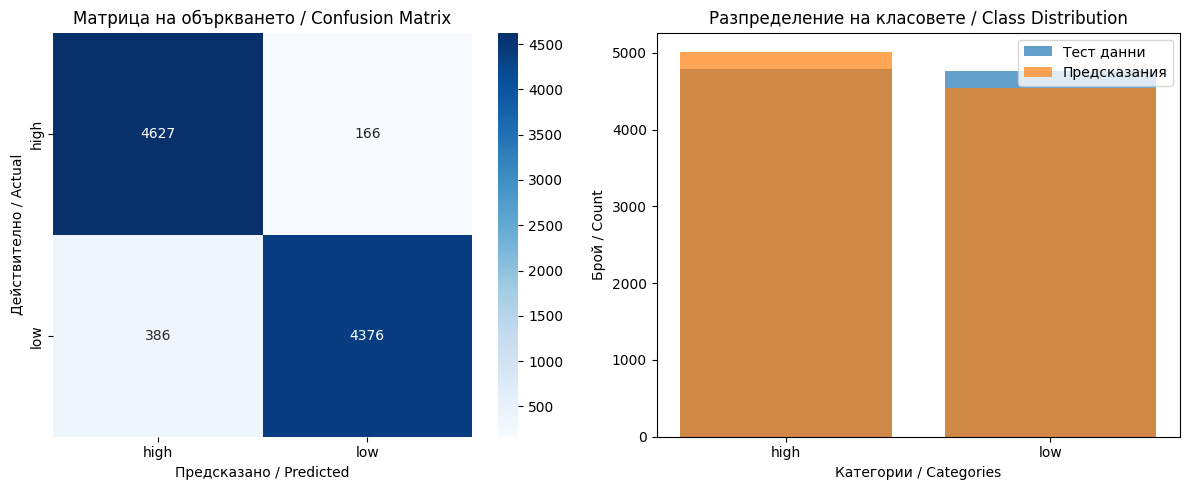

In [60]:
# Визуализация на резултатите
print("Създаване на визуализации")
# Матрица на объркването
# Confusion matrix
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Матрица на объркването / Confusion Matrix')
plt.xlabel('Предсказано / Predicted')
plt.ylabel('Действително / Actual')

# Разпределение на класовете
# Class distribution
plt.subplot(1, 2, 2)
unique, counts = np.unique(y_test, return_counts=True)
plt.bar([le.classes_[i] for i in unique], counts, alpha=0.7, label='Тест данни')
unique_pred, counts_pred = np.unique(y_pred, return_counts=True)
plt.bar([le.classes_[i] for i in unique_pred], counts_pred, alpha=0.7, label='Предсказания')
plt.title('Разпределение на класовете / Class Distribution')
plt.xlabel('Категории / Categories')
plt.ylabel('Брой / Count')
plt.legend()

plt.tight_layout()
plt.show()